In [ ]:
from sklearn.datasets import make_classification
import pandas as pd

# Criação de um dataset desbalanceado (95% vs 5%)
X, y = make_classification(
    n_samples=10000,
    n_features=5,
    weights=[0.95, 0.05], # Aqui definimos a proporção desequilibrada
    flip_y=0,
    random_state=42
)

# Colocando em um DataFrame do Pandas para facilitar a visualização
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 6)])
df['Target'] = y

print("Distribuição Original do Dataset:")
print(df['Target'].value_counts())

Distribuição Original do Dataset:
Target
0    9500
1     500
Name: count, dtype: int64


# Undersampling

In [ ]:
  v
# Aplicando Undersampling
undersampler = RandomUnderSampler(random_state=42)
#aplicar undersample
X_undersampled, y_undersampled = undersampler.fit_resample(X,y)
print("Distribuição do Dataset Undersampled:")
print(pd.Series(y_undersampled).value_counts())
#

Distribuição do Dataset Undersampled:
0    500
1    500
Name: count, dtype: int64


# Oversample

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Aplicando Undersampling
oversampler = RandomOverSampler(random_state=42)
#aplicar undersample
X_oversampled, y_oversampled = oversampler.fit_resample(X,y)
print("Distribuição do Dataset Undersampled:")
print(pd.Series(y_oversampled).value_counts())
#
print(X_oversampled)

Distribuição do Dataset Undersampled:
0    9500
1    9500
Name: count, dtype: int64
[[-0.7199064   0.86002516 -0.37677137 -1.1623586  -1.36753925]
 [-0.41036232  1.19473758 -0.62222895 -0.83272127 -1.17709769]
 [-0.49774514 -1.4371827   0.87920797 -0.03266298  0.46008782]
 ...
 [-1.5527048   0.35050401 -0.1397644  -0.58283818 -0.65817952]
 [ 0.53905033  0.51642246 -0.40810274  0.74116654  0.50875514]
 [-0.4084376  -0.3715396   0.17883687  0.37500056  0.47328923]]


# SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# Aplicando SMOTE
smote = SMOTE(random_state=42)
#aplicar undersample
X_smote, y_smote = smote.fit_resample(X,y)
print("Distribuição do Dataset Undersampled:")
print(pd.Series(y_smote).value_counts())
#
print(X_smote)

Distribuição do Dataset Undersampled:
0    9500
1    9500
Name: count, dtype: int64
[[-0.7199064   0.86002516 -0.37677137 -1.1623586  -1.36753925]
 [-0.41036232  1.19473758 -0.62222895 -0.83272127 -1.17709769]
 [-0.49774514 -1.4371827   0.87920797 -0.03266298  0.46008782]
 ...
 [-1.79844495  1.21165032 -0.82080302  0.6571726   0.1939689 ]
 [ 0.57506991 -1.08736261  0.45186115  1.66353291  1.90823549]
 [-1.2499281   0.2692787  -0.25747803  0.74004012  0.59202339]]


# K-NN

## pARTE 1

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap
sns.set_theme(style="whitegrid")

# 1. Coleta de Dados
df = pd.read_csv('base_iris.csv')

print(f"Dados carregados! Formato inicial: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.describe()

Dados carregados! Formato inicial: 150 linhas e 6 colunas.


,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,135.000000,150.000000,150.000000,141.000000
mean,74.500000,6.128889,3.136000,3.651333,1.365248
std,43.445368,3.471416,1.068103,2.083613,2.139025
min,0.000000,4.300000,2.000000,-10.000000,0.100000
25%,37.250000,5.100000,2.800000,1.525000,0.300000
50%,74.500000,5.800000,3.000000,4.300000,1.300000
75%,111.750000,6.400000,3.375000,5.100000,1.800000
max,149.000000,45.000000,15.000000,6.900000,25.000000


## PARTE 2

In [ ]:
# Remover coluna de índice sem nome
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Remover linhas sem o gabarito (target nulo)
df = df.dropna(subset=['target'])

# Remover duplicatas exatas
df = df.drop_duplicates()

print(f"Dados após limpeza estrutural: {df.shape[0]} linhas.")

# Visualização ANTES do tratamento
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns

Dados após limpeza estrutural: 146 linhas.


## PARTE 3

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Cofre fechado! Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras.")

Cofre fechado! Treino: 102 amostras | Teste: 44 amostras.


## PARTE 4

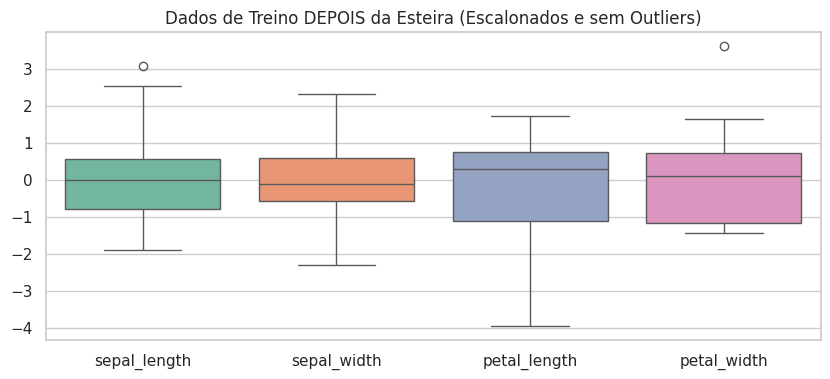

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 4.1 Criando o nosso próprio "Tratador de Outliers" para a Pipeline
class TratadorOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5):
        self.fator = fator
        self.limites = {}

    def fit(self, X, y=None):
        # A máquina "aprende" os limites APENAS olhando para os dados que entram aqui (Treino)
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.limites[col] = {
                'inferior': Q1 - self.fator * IQR,
                'superior': Q3 + self.fator * IQR
            }
        return self

    def transform(self, X):
        # A máquina aplica os limites aprendidos nos dados (Treino ou Teste)
        X_tratado = X.copy()
        for col, limites in self.limites.items():
            X_tratado[col] = X_tratado[col].clip(lower=limites['inferior'], upper=limites['superior'])
        return X_tratado

# 4.2 Construindo a Esteira (Pipeline)
esteira_processamento = Pipeline(steps=[
    ('outliers', TratadorOutliersIQR()),         # 1º: Corta os outliers usando regras do treino
    ('imputer', SimpleImputer(strategy='mean')), # 2º: Preenche nulos com a média limpa
    ('scaler', StandardScaler())                 # 3º: Coloca na mesma escala
])

# 4.3 Treinando a esteira e processando os dados de Treino
X_train_processado = esteira_processamento.fit_transform(X_train)
# 4.4 Codificando o Alvo (target)
codificador_alvo = LabelEncoder()
y_train_codificado = codificador_alvo.fit_transform(y_train)

# 4.3 Treinando a esteira e processando os dados de Treino
X_test_processado = esteira_processamento.fit_transform(X_test)
# 4.4 Codificando o Alvo (target)
codificador_alvo = LabelEncoder()
y_test_codificado = codificador_alvo.fit_transform(y_test)

# (Opcional) Visão dos dados de treino após passar pela esteira
X_train_vis = pd.DataFrame(X_train_processado, columns=cols_numericas)
plt.figure(figsize=(10, 4))
sns.boxplot(data=X_train_vis, palette="Set2")
plt.title("Dados de Treino DEPOIS da Esteira (Escalonados e sem Outliers)")
plt.show()

## PARTE 5 - ESCOLHA DO MODELO

In [ ]:
# configurando hiperparametros
modelo_knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean") #90%

#treinamento
modelo_knn.fit(X_train_processado, y_train_codificado)
#


KNeighborsClassifier(metric='euclidean')

## Aavaliação e validação


🏆 Exatidão (Acurácia) do KNN: 86.36%

              precision    recall  f1-score   support

      setosa       1.00      0.93      0.97        15
  versicolor       0.80      0.80      0.80        15
   virginica       0.80      0.86      0.83        14

    accuracy                           0.86        44
   macro avg       0.87      0.86      0.86        44
weighted avg       0.87      0.86      0.87        44



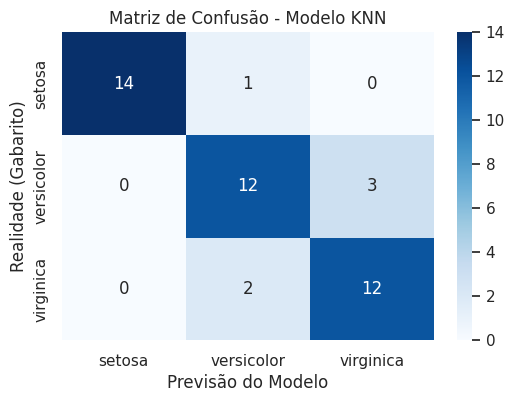

In [ ]:
# criando estimativas
y_pred_train = modelo_knn.predict(X_train_processado)
y_pred_test = modelo_knn.predict(X_test_processado)

# avaliando
acuracia_train = accuracy_score(y_train_codificado, y_pred_train)
acuracia_test = accuracy_score(y_test_codificado, y_pred_test)

# print(f"Acurácia no Treino: {acuracia_train:.2f}")
# print(f"Acurácia no Teste: {acuracia_test:.2f}")
print(f"\n🏆 Exatidão (Acurácia) do KNN: {acuracia_test * 100:.2f}%\n")
print(classification_report(y_test_codificado, y_pred_test, target_names=codificador_alvo.classes_))

# matriz de comnfusão
# matriz_confusao_train = confusion_matrix(y_train_codificado, y_pred_train)
matriz_confusao_test = confusion_matrix(y_test_codificado, y_pred_test)

matriz = confusion_matrix(y_test_codificado, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', # Mudei para Azul para diferenciar da árvore
            xticklabels=codificador_alvo.classes_,
            yticklabels=codificador_alvo.classes_)
plt.title('Matriz de Confusão - Modelo KNN')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Gabarito)')
plt.show()

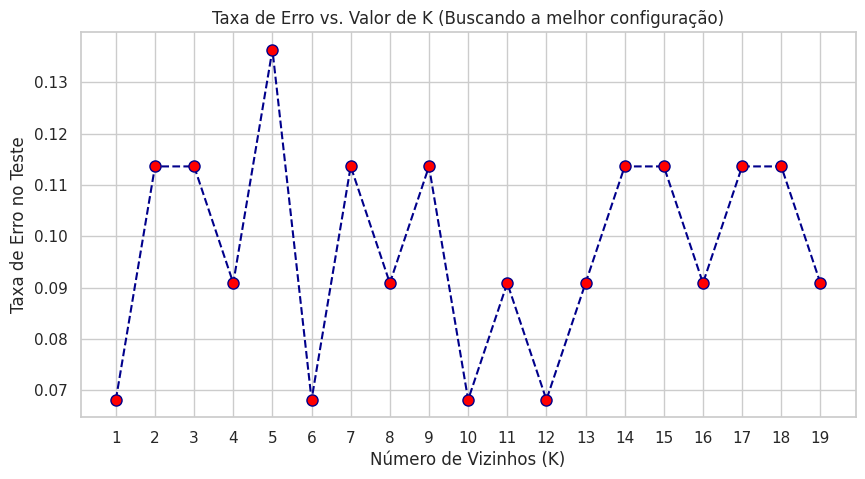

In [ ]:
import numpy as np
## graficco de cotovelo
taxa_erro = []
valores_k = range(1, 20)

for i in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn_temp.fit(X_train_processado, y_train_codificado)
    pred_i = knn_temp.predict(X_test_processado)
    # Calcula a média de vezes que a previsão foi diferente do gabarito real
    taxa_erro.append(np.mean(pred_i != y_test_codificado))

plt.figure(figsize=(10, 5))
plt.plot(valores_k, taxa_erro, color='darkblue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Taxa de Erro vs. Valor de K (Buscando a melhor configuração)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Taxa de Erro no Teste')
plt.xticks(valores_k)
plt.show()

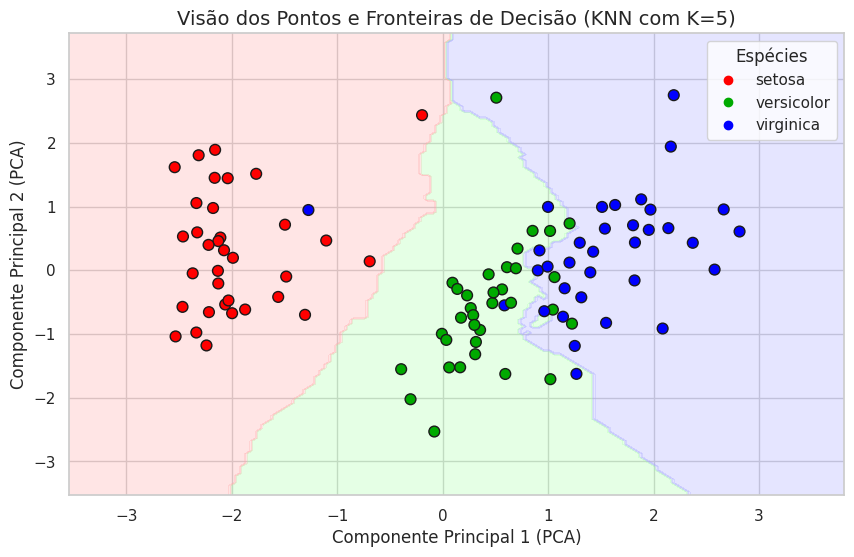

In [ ]:
### 8. Visualização do Espaço de Características (Os Pontos) ###
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 8.1 Comprimindo os dados de N dimensões para 2 dimensões (X e Y) para visualização
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_processado)

# 8.2 Treinando um modelo auxiliar no espaço 2D apenas para o gráfico
# (Usamos o K=5 que escolhemos no passo 5)
knn_visual = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_visual.fit(X_train_2d, y_train_codificado)

# 8.3 Criando o "mapa" (meshgrid) para pintar as fronteiras de decisão
# Definimos os limites do gráfico com uma pequena margem
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

# Criamos uma malha de milhares de pequenos pontos no fundo do gráfico
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 8.4 O modelo tenta prever a classe de cada um desses micro-pontos do fundo
# Isso vai criar as "regiões" de cor de cada categoria
Z = knn_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 8.5 Desenhando o gráfico
plt.figure(figsize=(10, 6))

# Definindo cores pastéis para o fundo e cores fortes para os pontos
cores_fundo = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cores_pontos = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

# Pinta as regiões de decisão (as "vizinhanças")
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cores_fundo)

# Plota os pontos reais de treinamento por cima
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_codificado,
                      cmap=cores_pontos, edgecolor='k', s=60)

# Ajustes visuais de rótulos e títulos
plt.title('Visão dos Pontos e Fronteiras de Decisão (KNN com K=5)', fontsize=14)
plt.xlabel('Componente Principal 1 (PCA)')
plt.ylabel('Componente Principal 2 (PCA)')

# Adiciona a legenda inteligente buscando os nomes reais (ex: setosa, versicolor...)
plt.legend(handles=scatter.legend_elements()[0],
           labels=codificador_alvo.classes_.tolist(),
           title="Espécies")

plt.show()